# MSA 2026 Phase 2 - Part 2: Maximum Temperature Prediction from Weather Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

## 1. Load and check the dataset

In [2]:
# low_memory=False because several columns mix numbers with text codes
weather = pd.read_csv("Summary of Weather.csv", low_memory=False)

print(f"Instances (rows) : {weather.shape[0]:,}")
print(f"Features (cols)  : {weather.shape[1]}")
weather.head(10)

Instances (rows) : 119,040
Features (cols)  : 31


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,MO,DA,PRCP,DR,SPD,MAX,MIN,MEA,SNF,SND,FT,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0,NaN,42,7,1,0.04,NaN,NaN,78.0,72.0,75.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0,NaN,42,7,2,0,NaN,NaN,84.0,71.0,78.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0,NaN,42,7,3,0.1,NaN,NaN,79.0,72.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0,NaN,42,7,4,0.1,NaN,NaN,80.0,72.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,7,5,0,NaN,NaN,80.0,71.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10001,1942-7-6,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,7,6,0,NaN,NaN,80.0,71.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10001,1942-7-7,T,NaN,28.333333,22.777778,25.555556,0,NaN,42,7,7,T,NaN,NaN,83.0,73.0,78.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10001,1942-7-8,3.556,NaN,26.666667,22.222222,24.444444,0,NaN,42,7,8,0.14,NaN,NaN,80.0,72.0,76.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10001,1942-7-9,T,NaN,27.222222,22.777778,25.000000,0,NaN,42,7,9,T,NaN,NaN,81.0,73.0,77.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10001,1942-7-10,3.556,NaN,25.555556,21.666667,23.333333,0,NaN,42,7,10,0.14,NaN,NaN,78.0,71.0,74.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# What is each column, what type is it, and how much of it is actually populated?
overview = pd.DataFrame({
    "dtype": weather.dtypes.astype(str),
    "non_null": weather.notna().sum(),
    "missing": weather.isna().sum(),
    "missing_pct": (weather.isna().mean() * 100).round(1),
    "n_unique": weather.nunique(),
})
overview

,dtype,non_null,missing,missing_pct,n_unique
STA,int64,119040,0,0.0,159
Date,object,119040,0,0.0,2192
Precip,object,119040,0,0.0,540
WindGustSpd,float64,532,118508,99.6,30
MaxTemp,float64,119040,0,0.0,149
MinTemp,float64,119040,0,0.0,132
MeanTemp,float64,119040,0,0.0,136
Snowfall,object,117877,1163,1.0,35
PoorWeather,object,34237,84803,71.2,38
YR,int64,119040,0,0.0,6


In [4]:
# Summary statistics for the numeric columns
weather.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
STA,119040.0,29659.44,20953.21,10001.00,11801.00,22508.00,33501.00,82506.00
WindGustSpd,532.0,37.77,10.30,18.52,29.63,37.04,43.06,75.93
MaxTemp,119040.0,27.05,8.72,-33.33,25.56,29.44,31.67,50.00
MinTemp,119040.0,17.79,8.33,-38.33,15.00,21.11,23.33,34.44
MeanTemp,119040.0,22.41,8.30,-35.56,20.56,25.56,27.22,40.00
YR,119040.0,43.81,1.14,40.00,43.00,44.00,45.00,45.00
MO,119040.0,6.73,3.43,1.00,4.00,7.00,10.00,12.00
DA,119040.0,15.80,8.79,1.00,8.00,16.00,23.00,31.00
DR,533.0,27.00,15.22,2.00,11.00,32.00,34.00,78.00
SPD,532.0,20.40,5.56,10.00,16.00,20.00,23.25,41.00


### What the dataset contains

- The dataset contains 119,040 daily weather records with 31 variables, collected from 159 weather stations (STA).
- Temperature is recorded in both Celsius and Fahrenheit. MaxTemp, MinTemp, and MeanTemp are measured in Celsius, while MAX, MIN, and MEA contain the same values in Fahrenheit.
- Nine columns are completely empty (FT, FB, FTI, ITH, SD3, RHX, RHN, RVG, WTE) and provide no useful information. Several other columns, including WindGustSpd, DR, SPD, PGT, and SND, have more than 95% missing values, making them unlikely to be useful for analysis.
- The precipitation-related columns (Precip, Snowfall, PRCP, and SNF) were imported as text because they contain the value "T", which represents a trace amount of rain or snow that is too small to measure accurately.
- The target variable, MaxTemp, contains no missing values, so no rows need to be removed before building the prediction model.

MaxTemp missing values: 0
count    119040.00
mean         27.05
std           8.72
min         -33.33
25%          25.56
50%          29.44
75%          31.67
max          50.00
Name: MaxTemp, dtype: float64


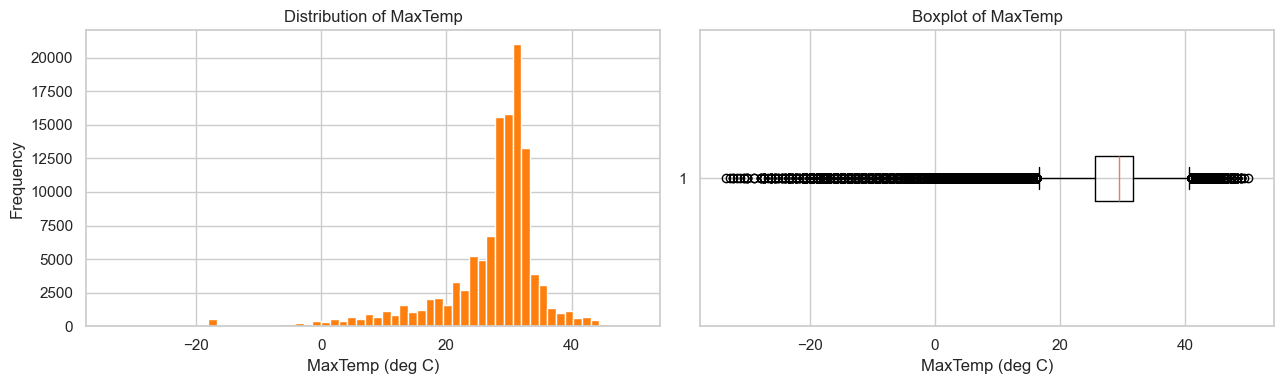

In [5]:
# Confirm the target has no gaps and see how it is distributed
print("MaxTemp missing values:", weather["MaxTemp"].isna().sum())
print(weather["MaxTemp"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(weather["MaxTemp"], bins=60, color="tab:orange")
axes[0].set_title("Distribution of MaxTemp")
axes[0].set_xlabel("MaxTemp (deg C)")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(weather["MaxTemp"], vert=False)
axes[1].set_title("Boxplot of MaxTemp")
axes[1].set_xlabel("MaxTemp (deg C)")
plt.tight_layout()
plt.show()

MaxTemp has an average of about 27°C, with a long left tail extending to around -33°C. Most observations come from warmer locations, while a smaller number were recorded at much colder stations, resulting in a negatively skewed distribution.

## 2. Clean the dataset, drop variables

### 2.1 Drop empty and near-empty columns

In [6]:
# A column that is entirely (or almost entirely) missing cannot inform a model
missing_pct = weather.isna().mean()

empty_cols = missing_pct[missing_pct == 1.0].index.tolist()
sparse_cols = missing_pct[(missing_pct >= 0.90) & (missing_pct < 1.0)].index.tolist()

print("100% empty  :", empty_cols)
print("\n>=90% empty :", sparse_cols)

df = weather.drop(columns=empty_cols + sparse_cols)
print(f"\nColumns: {weather.shape[1]} -> {df.shape[1]}")

100% empty  : ['FT', 'FB', 'FTI', 'ITH', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE']

>=90% empty : ['WindGustSpd', 'DR', 'SPD', 'SND', 'PGT']

Columns: 31 -> 17


Dropping these columns is reasonable because completely empty columns contain no useful information. Columns with more than 90% missing values would require extensive imputation, making the imputed values more influential than the original data.

### 2.2 Convert the text columns to numbers

In [7]:
# Precip / Snowfall / PRCP / SNF use "T" to mean a trace amount that was too small to measure.
# A trace is effectively zero, so we map it to 0 and coerce the rest to numeric.
text_numeric = ["Precip", "Snowfall", "PRCP", "SNF"]

for col in text_numeric:
    print(f"{col:<9} non-numeric values before: {pd.to_numeric(df[col], errors='coerce').isna().sum():>7,}")

for col in text_numeric:
    df[col] = pd.to_numeric(df[col].replace("T", 0.0), errors="coerce")

print()
for col in text_numeric:
    print(f"{col:<9} still non-numeric        : {df[col].isna().sum():>7,}")

Precip    non-numeric values before:  16,753
Snowfall  non-numeric values before:   1,207
PRCP      non-numeric values before:  18,685
SNF       non-numeric values before:   1,207

Precip    still non-numeric        :       0
Snowfall  still non-numeric        :   1,207
PRCP      still non-numeric        :   1,932
SNF       still non-numeric        :   1,163


In [8]:
# Parse the date so we can pull out a month for the seasonal analysis
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
print(df["Date"].min(), "->", df["Date"].max())
print("\nRemaining dtypes:")
print(df.dtypes)

1940-01-01 00:00:00 -> 1945-12-31 00:00:00

Remaining dtypes:
STA                     int64
Date           datetime64[ns]
Precip                float64
MaxTemp               float64
MinTemp               float64
MeanTemp              float64
Snowfall              float64
PoorWeather            object
YR                      int64
MO                      int64
DA                      int64
PRCP                  float64
MAX                   float64
MIN                   float64
MEA                   float64
SNF                   float64
TSHDSBRSGF             object
dtype: object


### 2.3 Correlation between the variables and `MaxTemp`

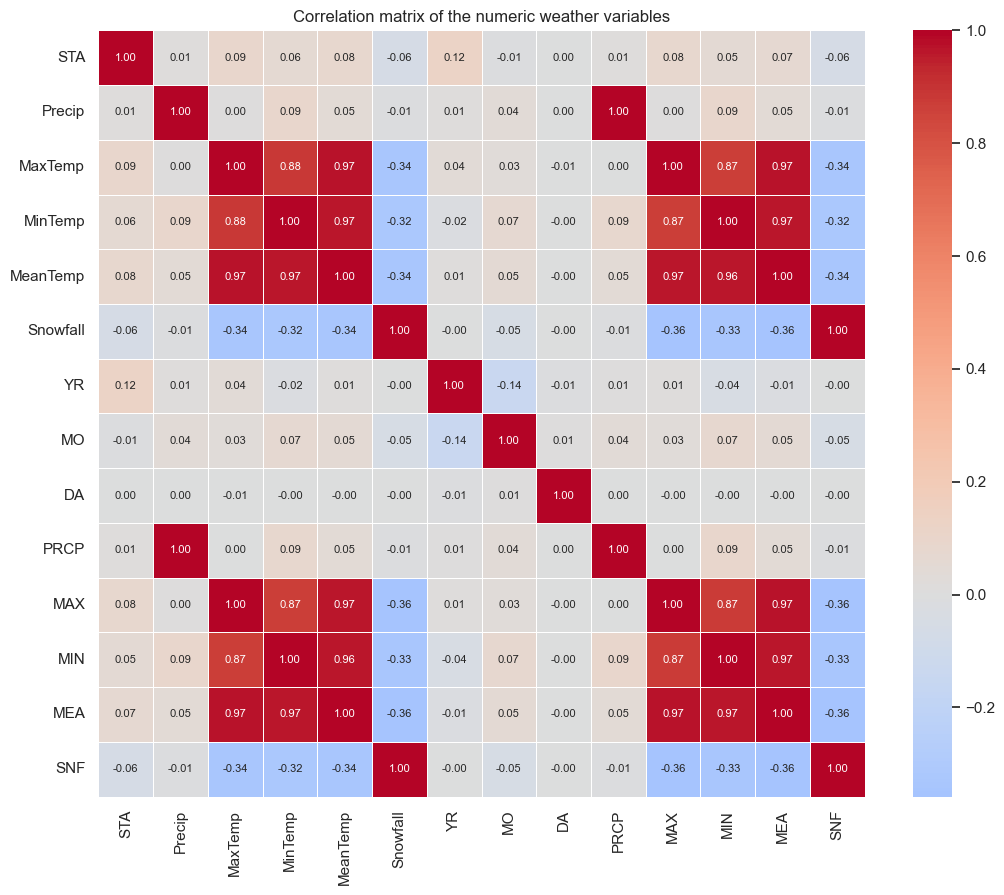

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation matrix of the numeric weather variables")
plt.tight_layout()
plt.show()

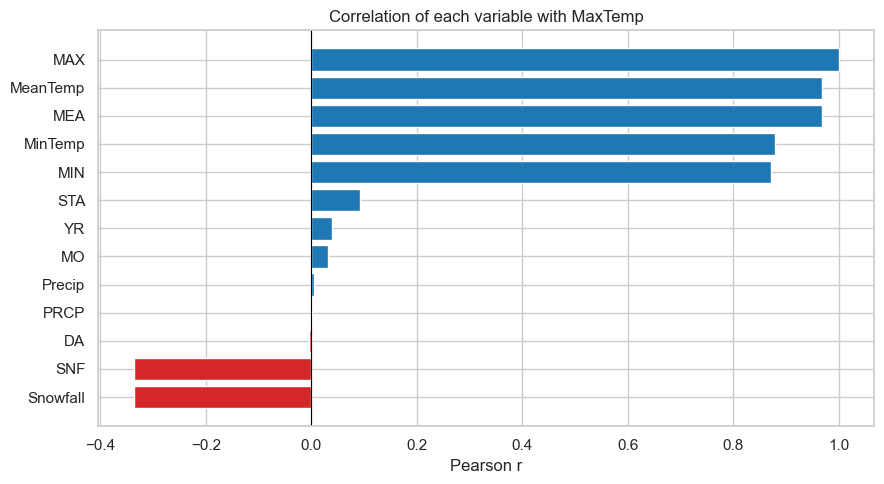

MAX         1.0000
MeanTemp    0.9690
MEA         0.9682
MinTemp     0.8784
MIN         0.8706
STA         0.0924
YR          0.0396
MO          0.0313
Precip      0.0045
PRCP        0.0018
DA         -0.0051
SNF        -0.3361
Snowfall   -0.3370


In [10]:
# Correlation of every variable with the target, ranked
target_corr = corr["MaxTemp"].drop("MaxTemp").sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = ["tab:red" if v < 0 else "tab:blue" for v in target_corr.values]
plt.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of each variable with MaxTemp")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print(target_corr.round(4).to_string())

**Reading the correlations**

| Variable | r with `MaxTemp` | Interpretation |
|---|---|---|
| `MAX` | **1.000** | not a predictor — this is `MaxTemp` itself converted to Fahrenheit |
| `MeanTemp` / `MEA` | 0.969 / 0.968 | the daily mean is calculated *from* the max, so it leaks the answer |
| `MinTemp` / `MIN` | 0.878 / 0.871 | **strong predictor** |
| `Snowfall` / `SNF` | -0.337 | moderate and intuitive — snow only falls on cold days |
| `Precip` / `PRCP` | ~0.00 | essentially no linear relationship |
| `STA`, `YR`, `MO`, `DA` | < 0.10 | identifiers and date parts |

In [11]:
# Verify the suspicion that MAX and MEA are not independent variables at all
f_from_c = df["MaxTemp"] * 9 / 5 + 32
print("Max abs difference between MAX and MaxTemp converted to Fahrenheit:",
      np.nanmax(np.abs(df["MAX"] - f_from_c)))

mean_from_minmax = (df["MaxTemp"] + df["MinTemp"]) / 2
agree = np.isclose(df["MeanTemp"], mean_from_minmax, atol=0.6).mean()
print(f"Share of rows where MeanTemp equals (MaxTemp + MinTemp) / 2: {agree:.1%}")

Max abs difference between MAX and MaxTemp converted to Fahrenheit: 8.000000661922968e-09
Share of rows where MeanTemp equals (MaxTemp + MinTemp) / 2: 99.5%


This confirms it. `MAX` is `MaxTemp` in Fahrenheit to within floating-point error, and `MeanTemp` is
the average of `MaxTemp` and `MinTemp` for the overwhelming majority of rows.

**Using either would be target leakage** — the model would score almost perfectly while learning
nothing, because we would be handing it the answer. In a real forecast we would not know today's
mean temperature before knowing today's maximum.

### 2.4 Drop the leaking, duplicated and irrelevant variables

In [12]:
drop_leakage = ["MAX", "MEA", "MeanTemp"]          # contain the target itself
drop_duplicate = ["MIN", "SNF", "PRCP"]            # Fahrenheit / duplicate copies of kept columns
drop_irrelevant = ["STA", "YR", "DA", "PoorWeather", "TSHDSBRSGF"]  # IDs and text codes

df_clean = df.drop(columns=drop_leakage + drop_duplicate + drop_irrelevant, errors="ignore")

print("Dropped for leakage    :", drop_leakage)
print("Dropped as duplicates  :", drop_duplicate)
print("Dropped as irrelevant  :", drop_irrelevant)
print("\nRemaining columns:", list(df_clean.columns))

Dropped for leakage    : ['MAX', 'MEA', 'MeanTemp']
Dropped as duplicates  : ['MIN', 'SNF', 'PRCP']
Dropped as irrelevant  : ['STA', 'YR', 'DA', 'PoorWeather', 'TSHDSBRSGF']

Remaining columns: ['Date', 'Precip', 'MaxTemp', 'MinTemp', 'Snowfall', 'MO']


**Reasoning for each group**

- **Leakage** — MAX, MEA, and MeanTemp all contain information about the target variable. MAX is simply MaxTemp in Fahrenheit, while MeanTemp (and its Fahrenheit equivalent MEA) is approximately the average of MaxTemp and MinTemp for 99.5% of the observations. Keeping these variables would introduce data leakage and produce unrealistically high model performance.

- **Duplicates** — MIN is MinTemp in Fahrenheit, while SNF and PRCP are duplicate versions of Snowfall and Precip. They contain the same information as the retained variables, so they add no predictive value and may introduce multicollinearity.

- **Irrelevant** — STA is a station identifier rather than a meaningful numerical feature, while YR and DA are date components that have no direct physical relationship with daily maximum temperature. PoorWeather and TSHDSBRSGF are sparse categorical weather condition codes rather than continuous meteorological measurements, making them unsuitable for this regression model.

### 2.5 Handle remaining missing values

In [13]:
print("Missing values before:")
print(df_clean.isna().sum())

# The remaining gaps are a tiny fraction of the data, so dropping is cleaner than imputing -
# imputing a temperature or a rainfall reading would invent weather that was never observed.
before = len(df_clean)
model_df = df_clean.dropna().copy()
print(f"\nRows: {before:,} -> {len(model_df):,} "
      f"(removed {before - len(model_df):,}, {1 - len(model_df)/before:.2%})")
print("Missing values after:", int(model_df.isna().sum().sum()))

Missing values before:
Date           0
Precip         0
MaxTemp        0
MinTemp        0
Snowfall    1207
MO             0
dtype: int64

Rows: 119,040 -> 117,833 (removed 1,207, 1.01%)
Missing values after: 0


### 2.6 The relationship we are going to model

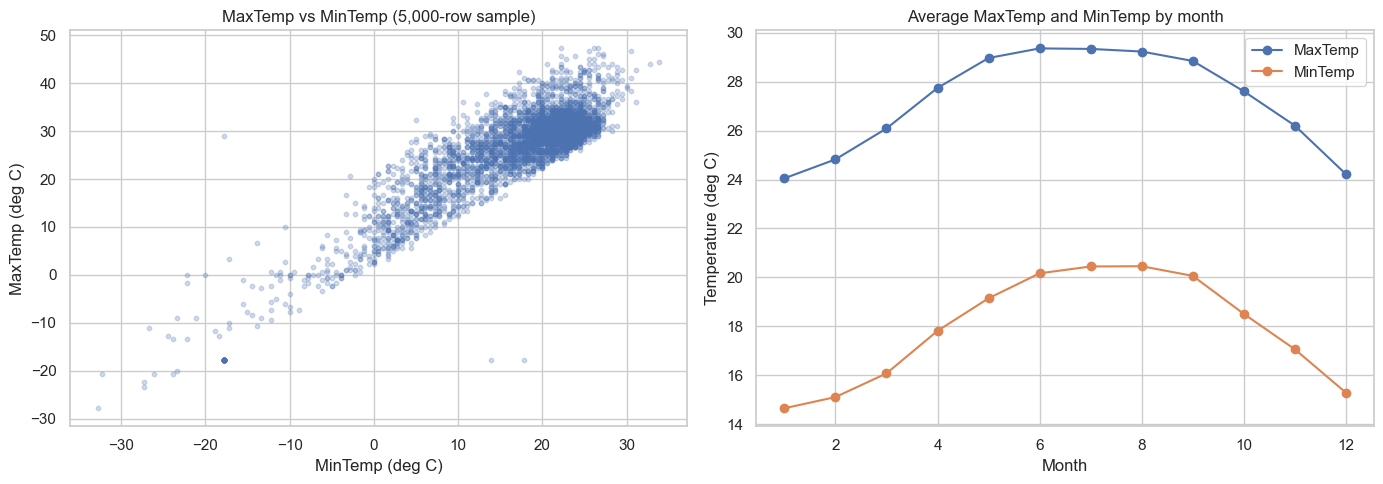

In [14]:
# Sample for readability - 117k overlapping points would be an unreadable blob
sample = model_df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample["MinTemp"], sample["MaxTemp"], alpha=0.25, s=10)
axes[0].set_title("MaxTemp vs MinTemp (5,000-row sample)")
axes[0].set_xlabel("MinTemp (deg C)")
axes[0].set_ylabel("MaxTemp (deg C)")

monthly = model_df.groupby(model_df["Date"].dt.month)[["MaxTemp", "MinTemp"]].mean()
monthly.plot(ax=axes[1], marker="o")
axes[1].set_title("Average MaxTemp and MinTemp by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Temperature (deg C)")

plt.tight_layout()
plt.show()

The scatter plot shows a clear and approximately linear relationship between MinTemp and MaxTemp. As minimum temperature increases, maximum temperature also tends to increase, supporting the strong positive correlation observed earlier.

The monthly averages of MinTemp and MaxTemp follow a similar seasonal pattern throughout the year. Their parallel movement further supports the close relationship between the two variables, explaining why MinTemp is a strong predictor of MaxTemp.

## 3. Select the feature(s) for the model, and explain the reason

In [15]:
# Compare candidate feature sets on identical rows and an identical split, so the comparison is fair
model_df["Month"] = model_df["Date"].dt.month
model_df["Month_sin"] = np.sin(2 * np.pi * model_df["Month"] / 12)
model_df["Month_cos"] = np.cos(2 * np.pi * model_df["Month"] / 12)

candidates = {
    "MinTemp only":                 ["MinTemp"],
    "MinTemp + Snowfall":           ["MinTemp", "Snowfall"],
    "MinTemp + Snowfall + Precip":  ["MinTemp", "Snowfall", "Precip"],
    "All of the above + month":     ["MinTemp", "Snowfall", "Precip", "Month_sin", "Month_cos"],
}

y_all = model_df["MaxTemp"]
results = []
for name, cols in candidates.items():
    Xtr, Xte, ytr, yte = train_test_split(model_df[cols], y_all, test_size=0.3, random_state=42)
    mdl = LinearRegression().fit(Xtr, ytr)
    pred = mdl.predict(Xte)
    results.append({
        "features": name,
        "n_features": len(cols),
        "R2": round(r2_score(yte, pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(yte, pred)), 4),
    })

pd.DataFrame(results)

/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/wendy/Desktop/2026-Phase-2-Data-Science-Wendy_Yuan/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarni

,features,n_features,R2,RMSE
0,MinTemp only,1,0.7554,4.1246
1,MinTemp + Snowfall,2,0.7595,4.0893
2,MinTemp + Snowfall + Precip,3,0.7654,4.0389
3,All of the above + month,5,0.7671,4.0245


### Selected feature: `MinTemp`

**Reasoning**

1. **It is the strongest legitimate predictor.** It is the strongest legitimate predictor. After removing the leakage variables (MAX, MEA, and MeanTemp), MinTemp has the highest correlation with MaxTemp (r = 0.878). The next strongest predictor, Snowfall, has a much weaker correlation (r = -0.337).

2. **The relationship is physically sensible.** Daily minimum and maximum temperatures are measured on the same day and are strongly influenced by the same weather conditions. As a result, days with higher minimum temperatures generally also have higher maximum temperatures.

3. **The extra features add almost nothing.** Using MinTemp alone achieved an R² of 0.7554. Adding Snowfall, Precip, and seasonal features increased R² to 0.7671 and reduced RMSE from 4.12°C to 4.02°C. Although performance improved, the gains were relatively small.

4. **Simplicity is a genuine advantage here.** Since the additional variables provide only marginal improvements, using MinTemp alone produces a model that is straightforward to interpret while maintaining good predictive performance.

Therefore, a simple linear regression model using MinTemp as the predictor was selected.

## 4. Split the dataset (70% for training, 30% for testing)

In [16]:
X = model_df[["MinTemp"]]  
y = model_df["MaxTemp"]    

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,        # 30% held out for testing
    random_state=42,      # fixed seed so the split is reproducible
)

print(f"Training set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Test set    : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X):.0%})")

# Sanity check: the two halves should look like the same population
print("\n", pd.DataFrame({
    "train": y_train.describe(),
    "test": y_test.describe(),
}).round(2))

Training set: 82,483 rows (70%)
Test set    : 35,350 rows (30%)

           train      test
count  82483.00  35350.00
mean      27.24     27.31
std        8.47      8.34
min      -33.33    -32.22
25%       25.56     25.56
50%       29.44     29.44
75%       31.67     31.67
max       50.00     48.89


The training and test sets have very similar means and standard deviations, indicating that the random split produced two comparable datasets and that the test set remains representative of the overall data.

## 5. Choose the algorithm, train and test the model

**Algorithm: Linear Regression (ordinary least squares).**

MaxTemp is a continuous variable, so this is a regression problem rather than a classification problem. The scatter plot in Section 2.6 shows a clear, approximately linear relationship between MinTemp and MaxTemp, making ordinary least squares a suitable starting model. Linear regression is also fast, requires little tuning, and produces an interpretable slope and intercept, which is useful because the aim is to explain the relationship between weather variables as well as make predictions.

In [17]:
# Train
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Fitted equation:  MaxTemp = {model.coef_[0]:.4f} * MinTemp + {model.intercept_:.4f}")

# Test - predict on data the model has never seen
y_pred = model.predict(X_test)

pd.DataFrame({
    "MinTemp": X_test["MinTemp"].values[:10],
    "Actual MaxTemp": y_test.values[:10],
    "Predicted MaxTemp": y_pred[:10].round(2),
    "Error": (y_test.values[:10] - y_pred[:10]).round(2),
})

Fitted equation:  MaxTemp = 0.9054 * MinTemp + 10.9820


,MinTemp,Actual MaxTemp,Predicted MaxTemp,Error
0,4.444444,13.333333,15.01,-1.67
1,21.666667,25.555556,30.60,-5.04
2,20.555556,30.000000,29.59,0.41
3,22.222222,33.888889,31.10,2.79
4,8.888889,28.333333,19.03,9.30
5,13.888889,30.555556,23.56,7.00
6,23.888889,34.444444,32.61,1.83
7,8.888889,25.555556,19.03,6.53
8,22.222222,33.333333,31.10,2.23
9,21.666667,30.555556,30.60,-0.04


**Interpreting the coefficients**

- **Slope 0.905** — For every 1°C increase in the daily minimum temperature, the predicted daily maximum temperature increases by approximately 0.905°C, on average.
- **Intercept 10.98** — When the daily minimum temperature is 0°C, the model predicts a daily maximum temperature of approximately 11°C.

## 6. Evaluate and Visualize model Performance

In [18]:
# Metrics on the held-out test set
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Training metrics too, so we can check for overfitting
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# A naive baseline: always predict the training mean
baseline = np.full(len(y_test), y_train.mean())
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline))

print(f"{'':<22}{'Train':>10}{'Test':>10}")
print(f"{'R^2':<22}{r2_train:>10.4f}{r2:>10.4f}")
print(f"{'RMSE (deg C)':<22}{rmse_train:>10.4f}{rmse:>10.4f}")
print(f"{'MAE  (deg C)':<22}{'':>10}{mae:>10.4f}")
print()
print(f"Baseline RMSE (predict the mean): {rmse_baseline:.4f} deg C")
print(f"Improvement over baseline       : {(1 - rmse/rmse_baseline):.1%}")

                           Train      Test
R^2                       0.7592    0.7554
RMSE (deg C)              4.1585    4.1246
MAE  (deg C)                        3.1561

Baseline RMSE (predict the mean): 8.3395 deg C
Improvement over baseline       : 50.5%


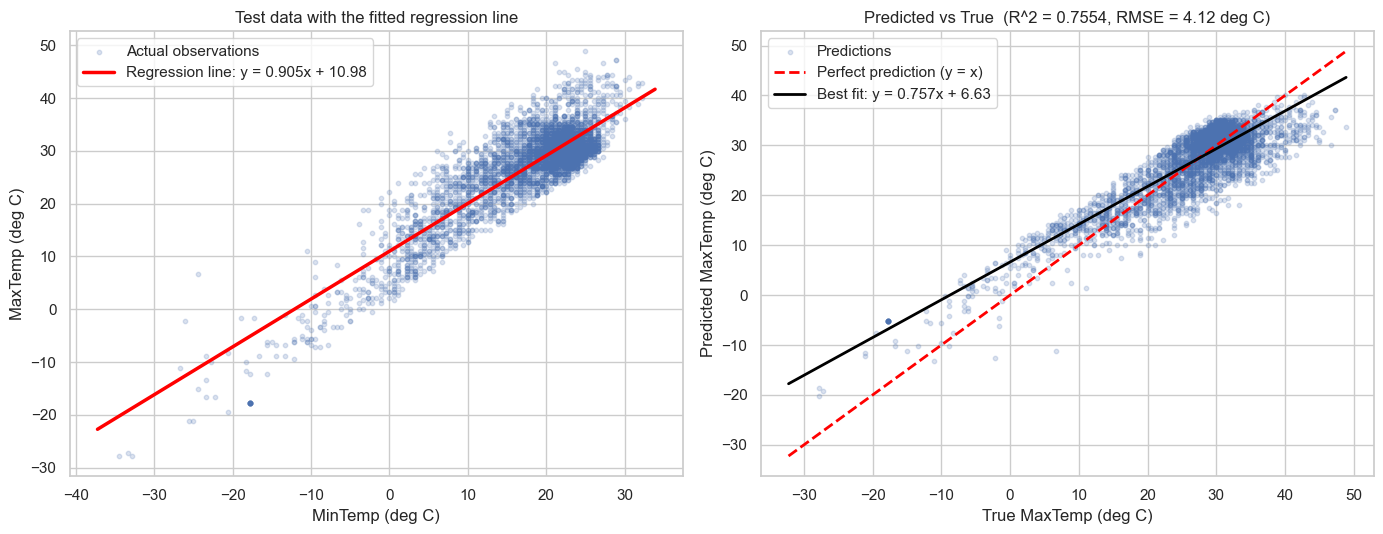

In [19]:
# Predicted vs true values, with the regression line
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: the fitted regression line drawn over the raw data
idx = np.random.RandomState(42).choice(len(X_test), size=5000, replace=False)
axes[0].scatter(X_test["MinTemp"].values[idx], y_test.values[idx],
                alpha=0.2, s=10, label="Actual observations")
line_x = np.linspace(X_test["MinTemp"].min(), X_test["MinTemp"].max(), 100)
line_y = model.predict(pd.DataFrame({"MinTemp": line_x}))
axes[0].plot(line_x, line_y, color="red", linewidth=2.5,
             label=f"Regression line: y = {model.coef_[0]:.3f}x + {model.intercept_:.2f}")
axes[0].set_xlabel("MinTemp (deg C)")
axes[0].set_ylabel("MaxTemp (deg C)")
axes[0].set_title("Test data with the fitted regression line")
axes[0].legend()

# Right: predicted vs true, with the ideal y = x line
axes[1].scatter(y_test.values[idx], y_pred[idx], alpha=0.2, s=10, label="Predictions")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="red", linewidth=2, linestyle="--",
             label="Perfect prediction (y = x)")

# Line of best fit through the predicted-vs-true cloud
fit = np.polyfit(y_test, y_pred, 1)
axes[1].plot(lims, np.polyval(fit, lims), color="black", linewidth=2,
             label=f"Best fit: y = {fit[0]:.3f}x + {fit[1]:.2f}")
axes[1].set_xlabel("True MaxTemp (deg C)")
axes[1].set_ylabel("Predicted MaxTemp (deg C)")
axes[1].set_title(f"Predicted vs True  (R^2 = {r2:.4f}, RMSE = {rmse:.2f} deg C)")
axes[1].legend()

plt.tight_layout()
plt.show()

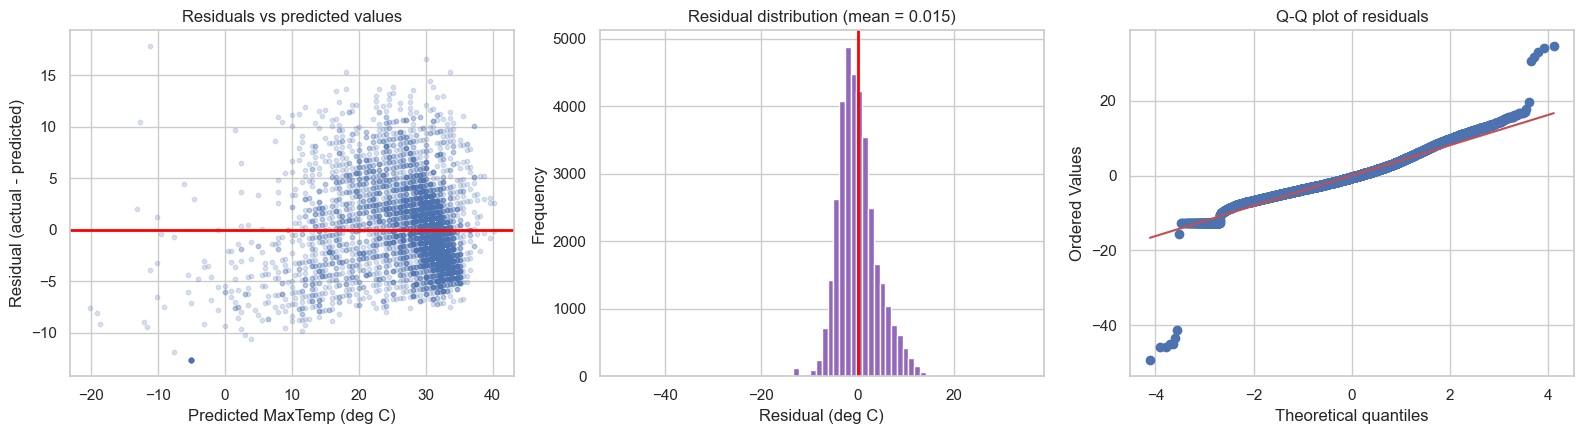

Residual mean         : 0.0153 deg C
Residual std dev      : 4.1246 deg C
Worst under-prediction: 34.56 deg C
Worst over-prediction : -49.38 deg C
Predictions within 5 deg C of the truth: 80.7%


In [20]:
# Residual diagnostics - where and how the model gets things wrong
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_pred[idx], residuals.values[idx], alpha=0.2, s=10)
axes[0].axhline(0, color="red", linewidth=2)
axes[0].set_xlabel("Predicted MaxTemp (deg C)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted values")

axes[1].hist(residuals, bins=70, color="tab:purple")
axes[1].axvline(0, color="red", linewidth=2)
axes[1].set_xlabel("Residual (deg C)")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Residual distribution (mean = {residuals.mean():.3f})")

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of residuals")

plt.tight_layout()
plt.show()

print(f"Residual mean         : {residuals.mean():.4f} deg C")
print(f"Residual std dev      : {residuals.std():.4f} deg C")
print(f"Worst under-prediction: {residuals.max():.2f} deg C")
print(f"Worst over-prediction : {residuals.min():.2f} deg C")
print(f"Predictions within 5 deg C of the truth: {(residuals.abs() <= 5).mean():.1%}")

## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

In [22]:
print(f"R^2  = {r2:.4f}")
print(f"RMSE = {rmse:.4f} deg C")

R^2  = 0.7554
RMSE = 4.1246 deg C


### The values

| Metric | Test-set value |
|---|---|
| **R²** | **0.7554** |
| **RMSE** | **4.12 °C** |

### What R² means

R² (the coefficient of determination) measures the proportion of the variance in MaxTemp explained by the model. An R² of 0.7554 means that approximately 75.5% of the variation in daily maximum temperature is explained by MinTemp. This indicates that MinTemp is a strong predictor of MaxTemp.

### What RMSE means

RMSE (Root Mean Squared Error) measures the typical prediction error in the same units as the target variable (°C). An RMSE of 4.12°C means that the model's predictions differ from the actual maximum temperatures by about 4.1°C on average. Since RMSE squares the prediction errors before averaging, it gives greater weight to larger errors than MAE.

### Reading the two together

- The RMSE (4.12°C) is much lower than the standard deviation of MaxTemp (8.34°C), indicating that the model predicts the data substantially better than simply using the average value.

- The RMSE (4.12°C) is higher than the MAE (3.16°C) because RMSE gives greater weight to larger prediction errors, suggesting the presence of some larger prediction errors.

- The training and test results are very similar (R²: 0.7592 vs 0.7554; RMSE: 4.16°C vs 4.12°C), indicating that the model generalises well with little evidence of overfitting.

## 8. Discuss the model performance based on the plot

### What the plots show

The residuals are centred around zero, indicating that the model does not systematically overestimate or underestimate MaxTemp. The residual histogram is approximately bell-shaped, suggesting that most prediction errors are relatively small.

However, the residuals-versus-predicted plot shows that the spread of the residuals is not completely constant. Larger errors occur more frequently for lower predicted temperatures, while predictions for higher temperatures are generally more consistent. The Q-Q plot also shows noticeable deviations from the reference line at both ends, indicating that the residuals are not perfectly normally distributed and that some extreme prediction errors exist.

Overall, the model performs well for a simple linear regression model, but its accuracy decreases for some extreme observations. Including additional weather or location-related features may further improve the model's performance.